### **ACID - PART 3 - Check channel treatment**

As a result of part 3 analysis channel 2 expresses a high variability in the quality. To a lower extent this is also true for channel 0. The present notebook checks how the quality of these channels relates to the treatment they received.

**Author:** Alessandro Ulivi (alessandro.ulivi.89@gmail.com)

**Last update (yyyy/mm/dd):** 2026/03/18


## **---------------------------**

### Import required modules

Run the following cell.

Don't modify the following cell.

In [1]:
# Import required modules
import datetime
import os
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.listdirNHF import listdirNHF
from utils.get_defaults import default_file_name
from utils.fov_axis_utils import get_fov_ch_shape
from image_quality_control.display_qc import plot_qc_by_channel_condition



### Specify the paths to input and output data directories - specify hyperparameters

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [2]:
# indicate the path to the directory storing the metadata file - NOTE: this is expected to be the metadata_df saved
# from part1 notebook
metadata_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"
# metadata_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\proc_metadata"

# indicate the path to the directory storing the fields of view
fov_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\fov"
# fov_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\fov"

# name of the metadata file - NOTE: this is expected to be the metadata_df saved
# from part2 notebook
# the following options are possible:
# 1) write the full name (extension included) of the csv file
# 2) write "default" or any other version with a uppercase letter (e.g. "Default")
# 3) leave an empty string: ""
# 4) write None (NOTE that this is not a string, there are no "", aka it is not "None")
# Options 2,3 and 4 will lead to the same behavior: the most recently saved csv file will be used.
# By default, the timestap of the last file modification is used. As an alternative it is possible to use the
# date saved in the name (change below parameter metadata_from_file_name to True -
# see utils.get_defaults.default_file_name documentation).
# metadata_file_name = "default"
metadata_file_name = "default"

# indicate whether to save the graphs generated in this notebook
save_graphs = True

# graph saving directory - this is the directory where the graphs generated in this notebook will be saved
# graph_saving_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\develop\260109_QCs\graphs"
graph_saving_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train"



# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

# # --- parameters to select the train set ---
# indicate the name of the column indicating whether the row belongs to train or test set
is_train_column="is_train"

# indicate the value signalling that a row (aka a field of view) belongs to the train set
train_val=1

# # --- parameters used for importing the default metadata dataframe ---
# Indicate the part of the file name to use to select files into metadata_directory to be used for selecting the default
# file
default_metadata_file_target = ".csv"
default_metadata_file_exclude = None

# Indicate whether to extract the date information from the file name when selecting the default file
# If False, the date will be extracted from the file's last modified timestamp, if True, from the file name.
# If from_file_name is True, the parameters *_default_separator and *_default_date_position
# should be used to indicate, respectively the separator to use for splitting the file name into tokens and
# the position of the token containing the date information. In addition, the date format used to include the date in the file name
# should be indicated using the parameters *_default_date_format.
# For example, if metadata_from_file_name is True, and the file name is "251126_plate_layout.csv",
# "_" is used as separator, 0 as date position, and '%Y%m%d' as date format.
# Ref to utils.get_defaults.default_file_name for more details.
metadata_from_file_name = False

# separator - used to split the file name and extract the information token with the date
# if metadata_from_file_name is True
metadata_default_separator = '_'

# date position - the position of the date information token after splitting the file name using file_name_separator (above)
# used if metadata_from_file_name is True
metadata_default_date_position = 0

# date format - the format used for including the date in the file name to be opened by default
# used if metadata_from_file_name is True
metadata_default_date_format='%Y%m%d'

# reverse - if True, the file with the most recent date will be returned by default - if False, the opposite
metadata_default_reverse = True


# --- parameters for quality control calculation ---
# channel axis to be passed to quality control functions in order to calculate quality control
# values of individual channels
channel_axis = 0

# field of view column name in the metadata dataframe
fov_column_name = "ome_tif_file_name"

# null value to be used to fill quality control metrics columns when they can't be calculated
null_value = np.nan

# plls column name
plls_column_name = "plls"

# # low percentile value to be used for calculating the extreme intensity percentile fraction
# # quality control metric
# low_percentile = 2

# # high percentile value to be used for calculating the extreme intensity percentile fraction
# # quality control metric
# high_percentile = 98

# bottom percentile fraction column name
bottom_perc_fract_column_name = "bottom_percentile_fraction"

# top percentile fraction column name
top_perc_fract_column_name = "top_percentile_fraction"

# mean over std column name
mean_over_std_column_name = "mean_over_std"


# --- parameters for quality control visualization ---
# treatment column name for quality control visualization
treatment_clm = "treatment"

# column name for the x-axis in quality control plots per treatment
qc_treatment_x_axis_column_name = "treatment"
# qc_well_x_axis_column_name = "well"

# channel separator used when saving multiple channel measurements into single dataframe columns
ch_measurement_separator = '-'


# --- parameters for file saving ---
# separator used for saved file names
save_file_name_separator = '_'

# project
project_name = "ACID"

# include indexes when saving pandas dataframes as csv files
save_csv_index = False # if False, the index will not be saved as a separate column in the csv file

# hyperparameters saving date format
hyperparameters_date_format = '%Y%m%d-%H%M%S'

# hyperparameters savingword
hyperparameters_savingword = "hyperparameters"

# hyperparameters file suffix
hyperparameters_file_suffix = f"part{save_file_name_separator}3extra.csv"

# qc graphs saving date format
qc_graphs_date_format = '%Y%m%d'

# qc graphs suffix
qc_graphs_suffix = f".png"

# plls per channel and treatment savingword
plls_per_channel_treatment_savingword = f"plls{save_file_name_separator}ch{save_file_name_separator}treatment"

# percentile fraction per channel and treatment savingword
perc_fract_per_ch_treatment_savingword = f"perc{save_file_name_separator}fract{save_file_name_separator}ch{save_file_name_separator}treatment"

# mean over std per channel and treatment savingword
mean_over_std_per_ch_treatment_savingword = f"mean{save_file_name_separator}over{save_file_name_separator}std{save_file_name_separator}ch{save_file_name_separator}treatment"


# --- parameters for saving secondary information ---
# indicate the name of the directory for saving secondary outputs -
# this directory is used to store the hyperparameters used per each run of the pipeline
secondary_output_directory = "secondary_output"
exist_ok = True # if the secondary output directory already exists, do not raise an error



### Create secondary output directory if it doesn't exist - this directory is used to store the hyperparameters used per each run of the pipeline

Run the following cell.

Don't modify the following cell.

In [3]:
# # check if using the default output_directory
# if output_directory==None or output_directory.lower()=="default" or output_directory=="":

#     print("Using the default output directory, which is the same as the metadata directory.")
    
#     # if using the default output directory, set the output directory to be the same as the metadata directory
#     output_directory = metadata_directory
# else:
#     # if not using the default output directory, ensure that it is a path
#     output_directory = Path(output_directory).resolve() # ensure that the output directory is an absolute path

# create the path to secondary_output directory
secondary_output_path = os.path.join(os.getcwd(), secondary_output_directory)

# create the secondary_output directory if it doesn't exist
if not os.path.exists(secondary_output_path):
    os.makedirs(secondary_output_path, exist_ok=exist_ok)


#### Open the metadata dataframe - this is expected to be the output of part 3

Run the following cell.

Don't modify the following cell.

In [4]:

# check if using the default metadata data frame (the most recently saved)
if metadata_file_name==None or metadata_file_name.lower()=="default" or metadata_file_name=="":
    
    # import target files in the metadata_directory
    metadata_files = listdirNHF(metadata_directory,
                                target=default_metadata_file_target,
                                exclude=default_metadata_file_exclude)
    
    # get the default metadata file
    metadata_file_name = default_file_name(file_list=metadata_files,
                                           from_file_name=metadata_from_file_name,
                                           directory_path=metadata_directory,
                                           separator=metadata_default_separator,
                                           date_position=metadata_default_date_position,
                                           date_format=metadata_default_date_format,
                                           reverse=metadata_default_reverse)
    
    print(f"using {metadata_file_name} as default metadata file")


# open the metadata file
metadata_df_i = pd.read_csv(os.path.join(metadata_directory, metadata_file_name))

# copy metadata_df
metadata_df = metadata_df_i.copy()

# # display the metadata dataframe
# metadata_df



using 20260318_ACID_metadata_part_3.csv as default metadata file


#### Select train data set - NOTE: the metadata_df is updated into a metadata_df which does not contain the test data

Run the following cell.

Don't modify the following cell.

In [5]:
# Select only the train set and update metadata_df
metadata_df = metadata_df[metadata_df[is_train_column] == train_val]

# assert proper selection of train set
assert metadata_df.shape[0] > 0, "No rows in metadata_df belong to the train set."
assert all(metadata_df[is_train_column] == train_val), "Not all rows in metadata_df belong to the train set."

# Display the metadata dataframe
metadata_df


,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,infectious_organism,...,top_percentile_fraction-1,top_percentile_fraction-2,top_percentile_fraction-3,top_percentile_fraction-4,mean_over_std-0,mean_over_std-1,mean_over_std-2,mean_over_std-3,mean_over_std-4,flag
0,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A1,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A1...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,0.020022,0.020022,0.022416,0.020002,2.585605,1.195264,1.445345,27.645255,17.653226,0
1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,0.020003,0.020005,0.021515,0.020010,2.159470,1.592156,1.751387,25.278685,15.561817,0
2,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A5,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,0.020011,0.020014,0.022187,0.020006,2.179615,1.817711,1.600485,27.096500,15.971792,0
3,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,0.020000,0.020003,0.021979,0.020007,2.243834,1.904663,1.444320,27.040939,15.403914,0
4,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,B7,251211,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,DENV2,...,0.020019,0.020011,0.021446,0.020018,2.278106,2.020556,1.607375,27.431643,15.968074,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,F3,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_F3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,0.020432,0.020003,0.021571,0.020041,1.960308,19.792109,1.524763,27.921094,13.773708,0
819,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G2,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,0.020045,0.020019,0.021691,0.020070,1.827073,8.612130,1.740165,27.868546,15.414203,0
820,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G4,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,0.020598,0.020002,0.021369,0.020025,1.789514,14.308079,1.693619,27.543277,14.619977,0
821,H7_DENV2_MOI1_40h_fixed_stained_well8.nd2,G6,251211,H7_DENV2_MOI1_40h_fixed_stained_well8_A07p4_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.4,H7,DENV2,...,0.020006,0.020002,0.021918,0.020114,2.301495,5.008123,1.532941,18.554031,17.062070,0


#### Get the number of channels of the fields of view

Run the following cell.

Modify the following cell.

In [6]:
# get the number of channels in the images indicated in the metadata dataframe
fov_shape, num_channels, shape_of_channels = get_fov_ch_shape(metadata_df,
                                                              fov_directory,
                                                              fov_clm=fov_column_name,
                                                              channel_axis=channel_axis,
                                                              null_value=null_value)


field of view shape: (5, 1024, 1024)
number of channels found: 5
shape of channels: (1024, 1024)


#### Visualize PLLS values per channel and treatment

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_plls_ch_treatment.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


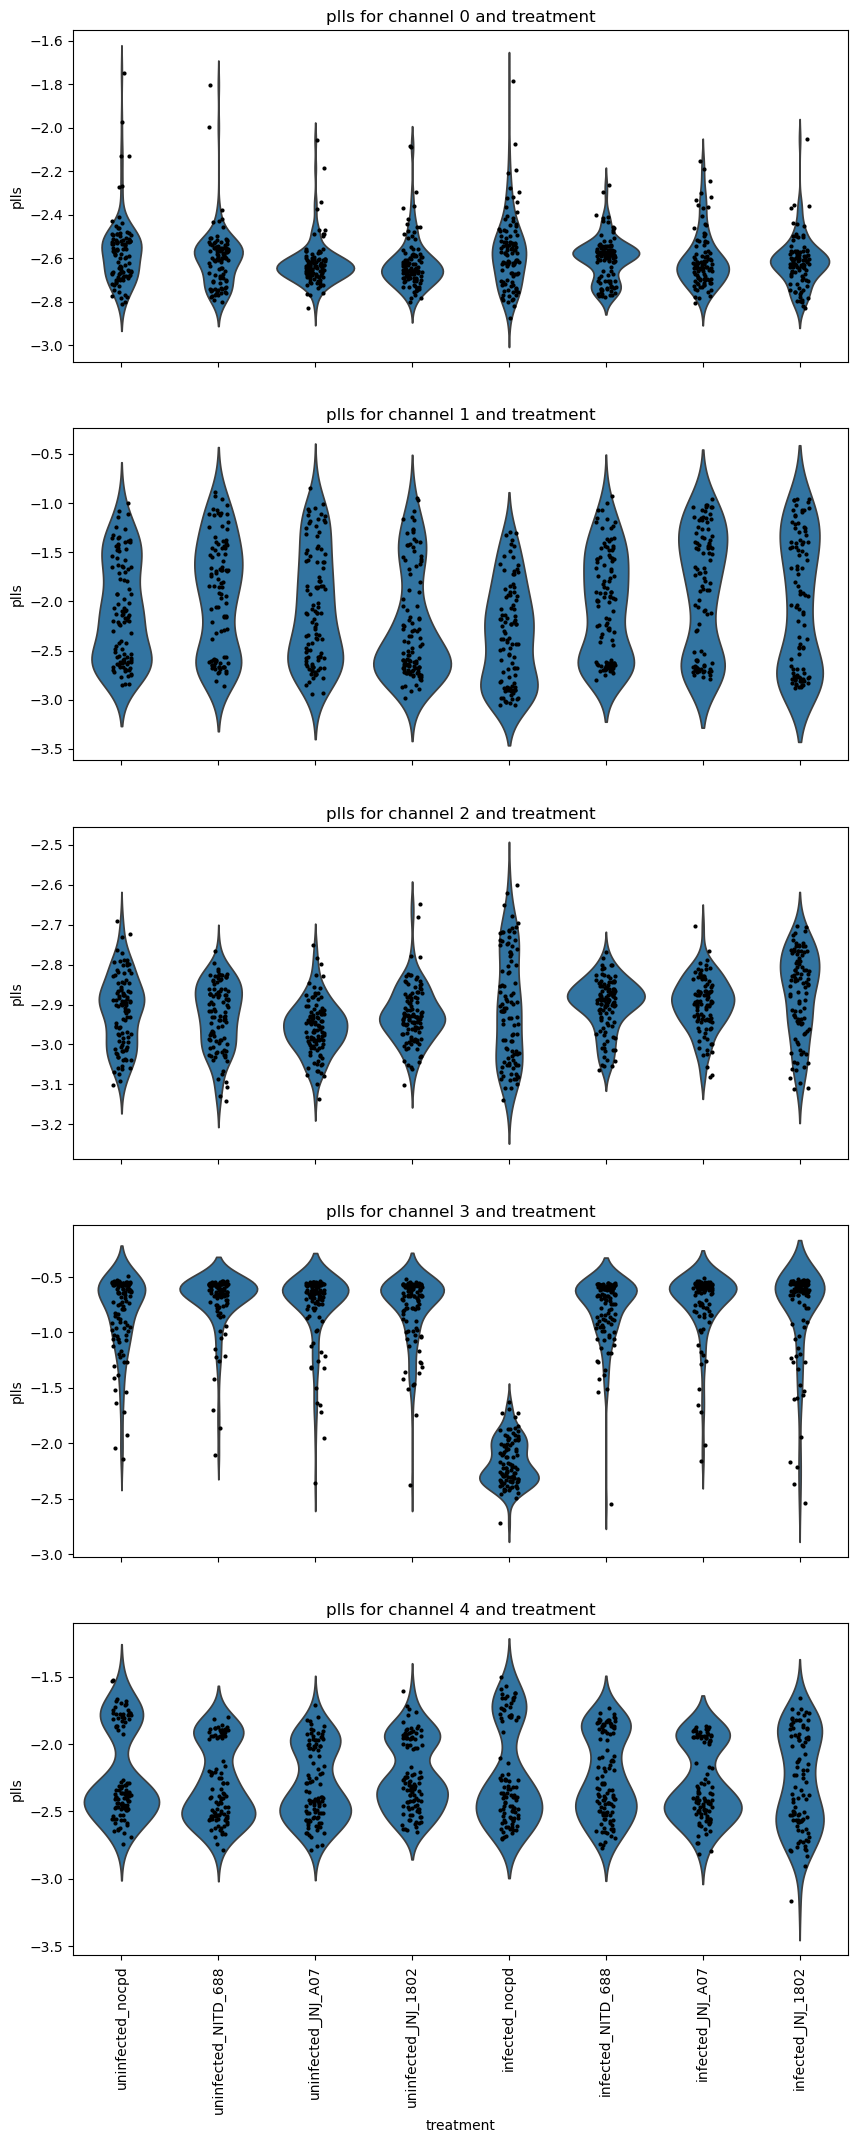

In [7]:
fig1, ax1 = plt.subplots(num_channels, 1,figsize=(10,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=plls_column_name,
                             condition_clm=treatment_clm,
                             ax=ax1,
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

plt.xticks(rotation=90)

# save graph
if save_graphs:
    plls_per_ch_exp_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{plls_per_channel_treatment_savingword}{qc_graphs_suffix}"
    fig1.savefig(os.path.join(graph_saving_directory, plls_per_ch_exp_saving_name))
    print(f"graph saved as {plls_per_ch_exp_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")


#### Visualize EXTREME INTENSITY PERCENTILE FRACTION values per channel and treatment

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_perc_fract_ch_treatment.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


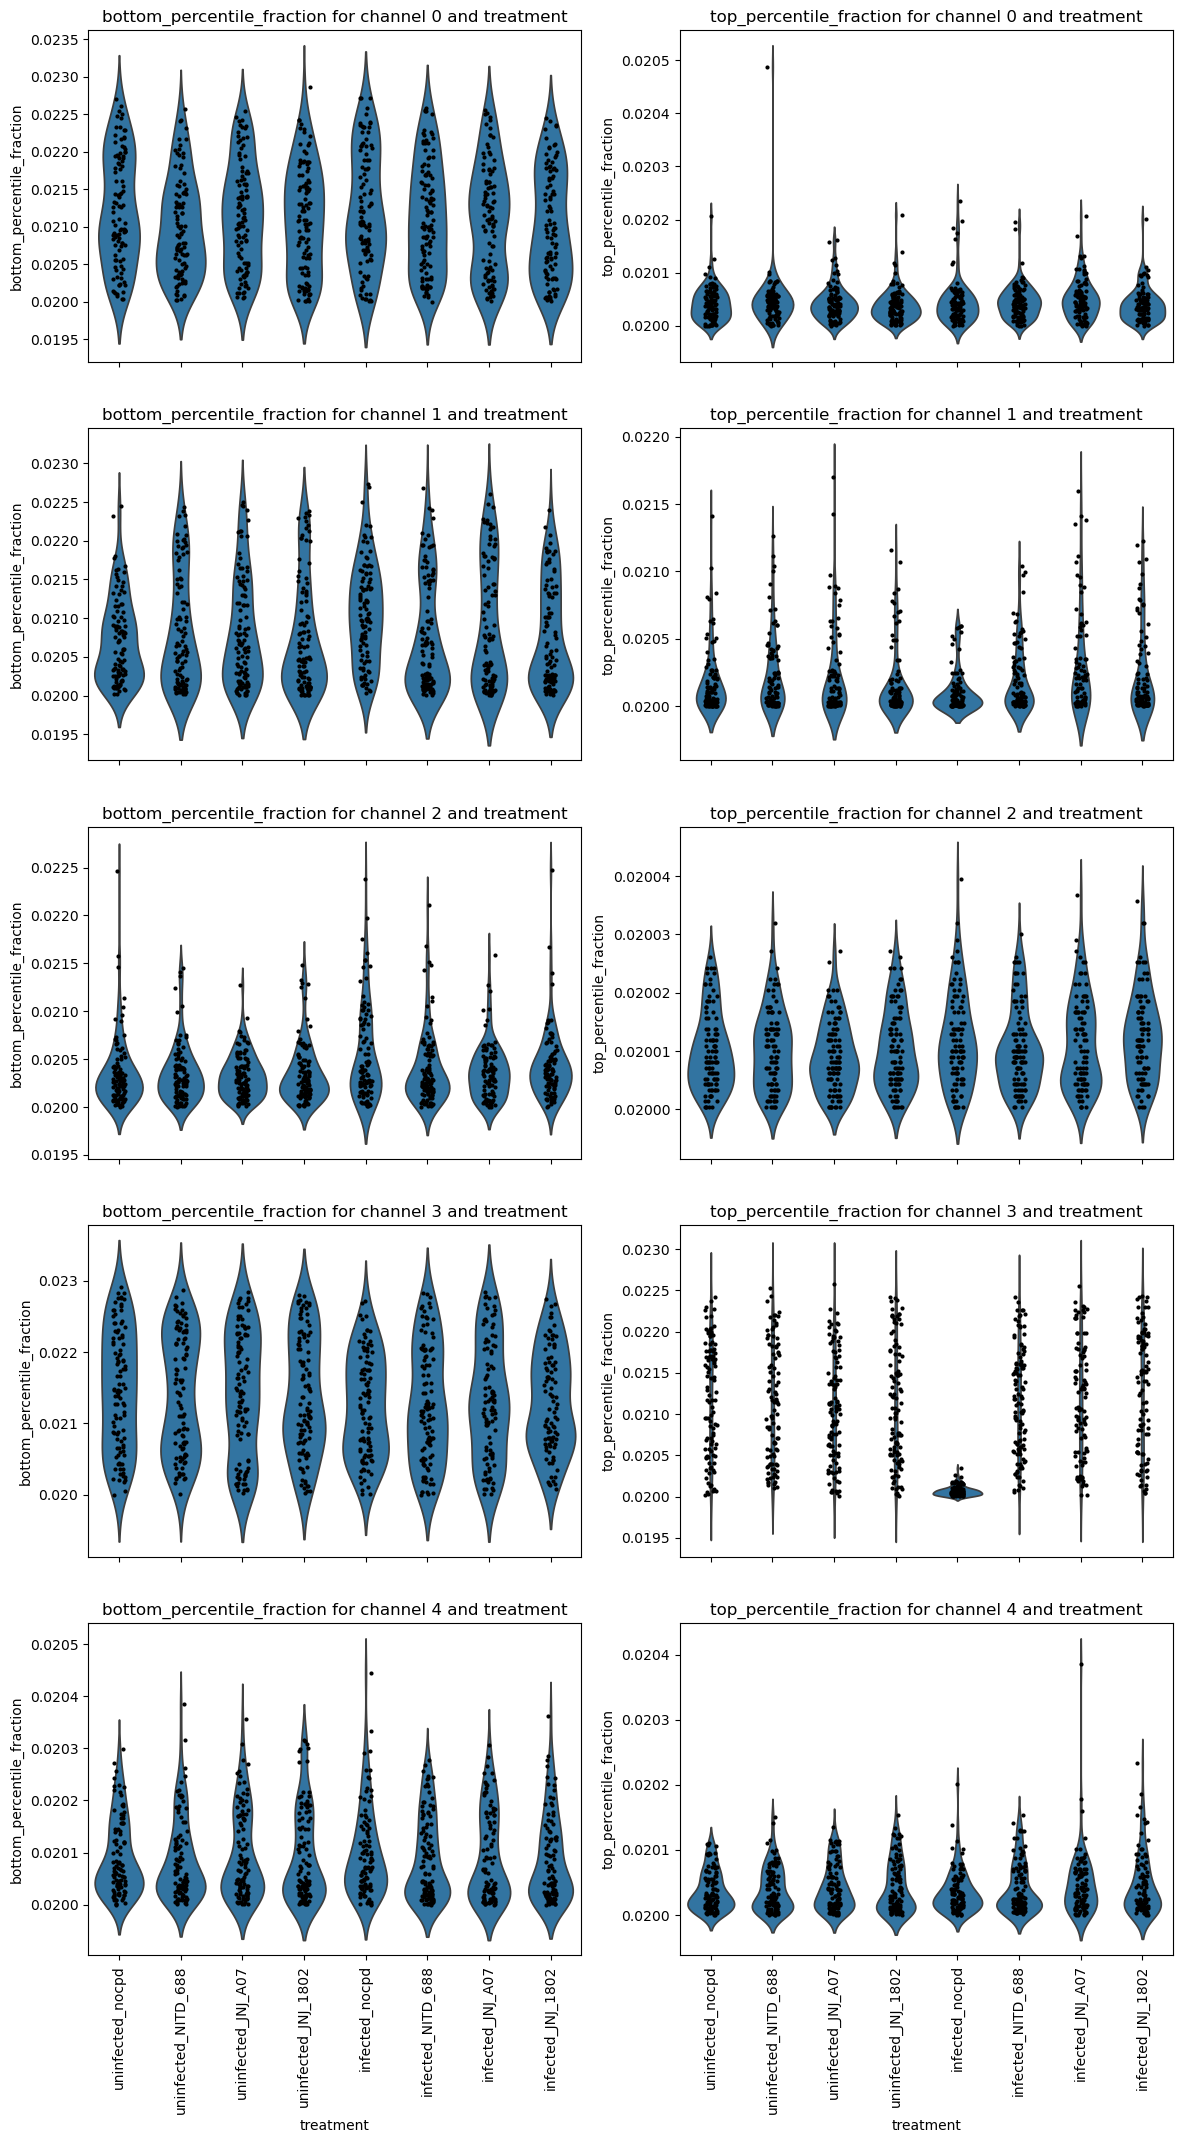

In [8]:
fig4, ax4 = plt.subplots(num_channels, 2, figsize=(14,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=bottom_perc_fract_column_name,
                             condition_clm=treatment_clm,
                             ax=ax4[:,0],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=top_perc_fract_column_name,
                             condition_clm=treatment_clm,
                             ax=ax4[:,1],
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

for a_x in ax4.flatten():
    a_x.tick_params(axis='x', labelrotation=90)

# save graph
if save_graphs:
    perc_fract_per_ch_treatment_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{perc_fract_per_ch_treatment_savingword}{qc_graphs_suffix}"
    fig4.savefig(os.path.join(graph_saving_directory, perc_fract_per_ch_treatment_saving_name))
    print(f"graph saved as {perc_fract_per_ch_treatment_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")



#### Visualize MEAN OVER STD values per channel and treatment

Run the following cell.

Modify the following cell.

graph saved as 20260318_ACID_mean_over_std_ch_treatment.png in Z:\AlessandroUlivi_Data\projects\ACID\develop\260318_QCs\train


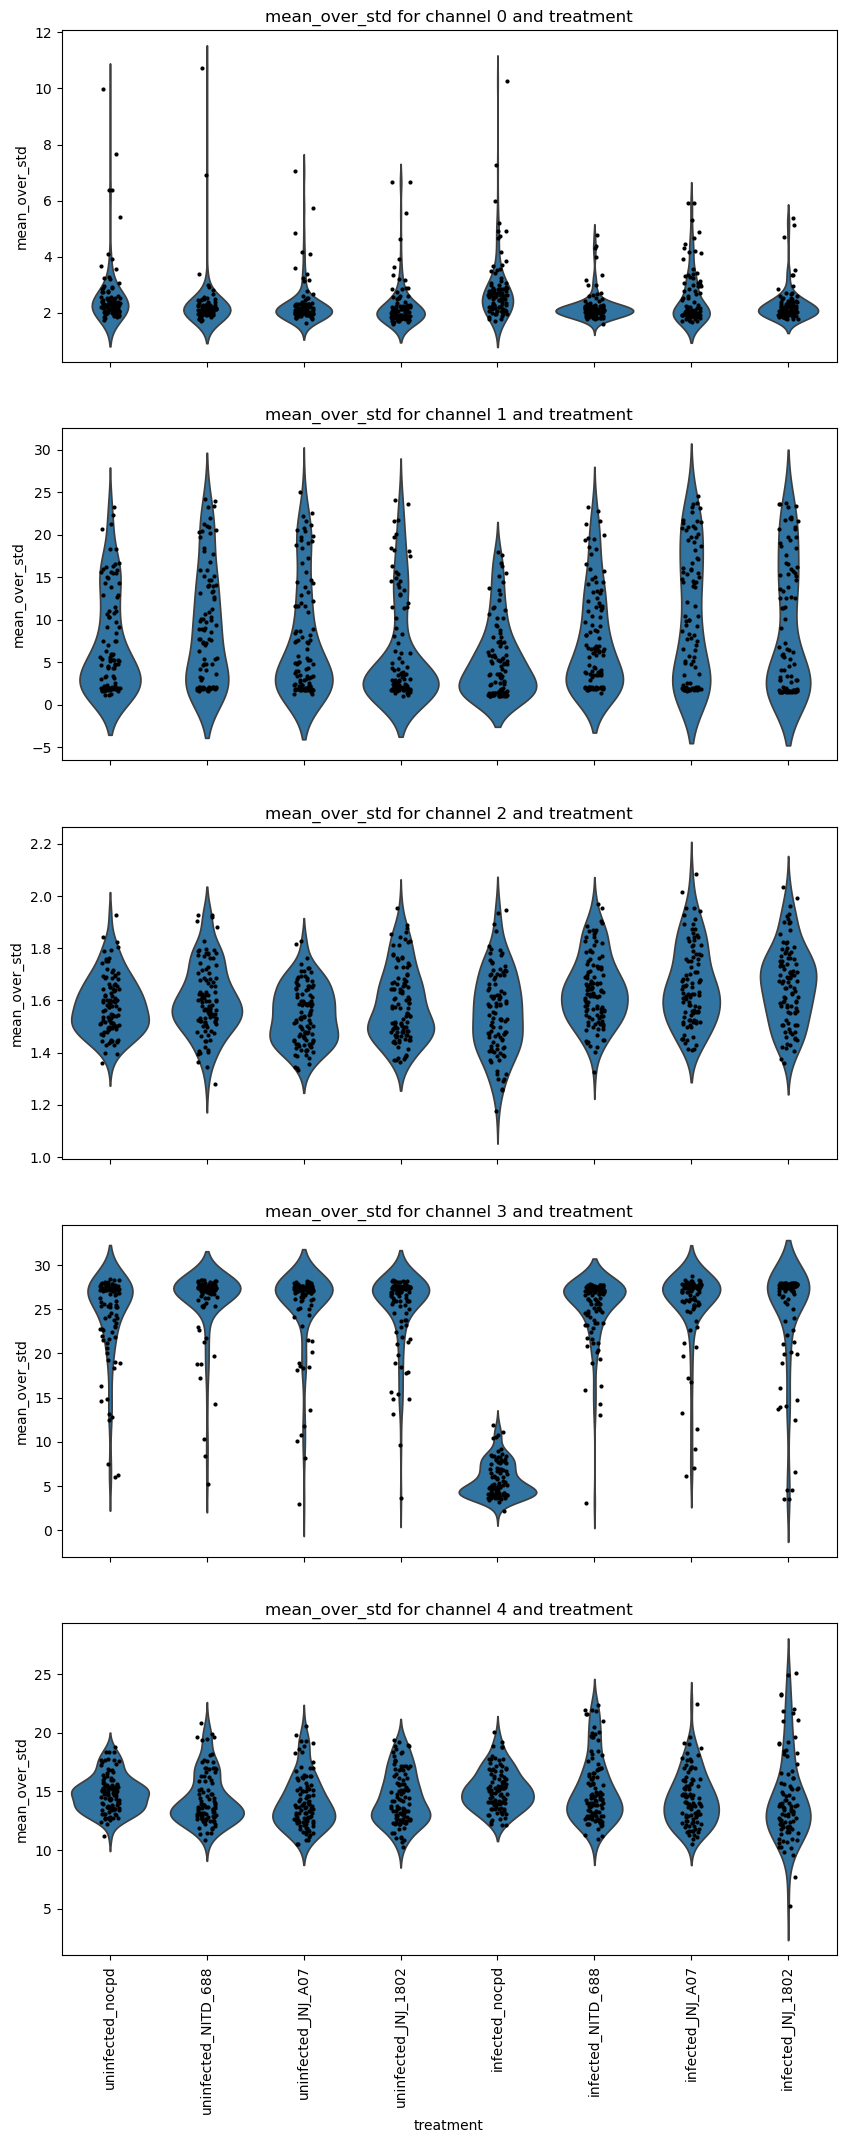

In [9]:
fig7, ax7 = plt.subplots(num_channels, 1,figsize=(10,5*num_channels), sharex=True, sharey=False)

plot_qc_by_channel_condition(metadata_df=metadata_df,
                             qc_clm=mean_over_std_column_name,
                             condition_clm=treatment_clm,
                             ax=ax7,
                             num_channels=num_channels,
                             ch_measurement_separator=ch_measurement_separator)

plt.xticks(rotation=90)

# save graph
if save_graphs:
    mean_over_std_per_ch_treatment_saving_name = f"{datetime.datetime.now().strftime(qc_graphs_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{mean_over_std_per_ch_treatment_savingword}{qc_graphs_suffix}"
    fig7.savefig(os.path.join(graph_saving_directory, mean_over_std_per_ch_treatment_saving_name))
    print(f"graph saved as {mean_over_std_per_ch_treatment_saving_name} in {graph_saving_directory}")
else:
    print("graph not saved, set save_graphs to True to save the graph")


### Save hyperparameters

Run the following cell.

Don't modify the following cell.

In [10]:
# # collect hyperparameters in a dictionary

hyperparameter_dict = {
'metadata_directory':metadata_directory,
'fov_directory':fov_directory,
'metadata_file_name':metadata_file_name,
'save_graphs':save_graphs,
'graph_saving_directory':graph_saving_directory,
'is_train_column':is_train_column,
'train_val':train_val,
'default_metadata_file_target':default_metadata_file_target,
'default_metadata_file_exclude':default_metadata_file_exclude,
'metadata_from_file_name':metadata_from_file_name,
'metadata_default_separator':metadata_default_separator,
'metadata_default_date_position':metadata_default_date_position,
'metadata_default_date_format':metadata_default_date_format,
'metadata_default_reverse':metadata_default_reverse,
'channel_axis':channel_axis,
'fov_column_name':fov_column_name,
'null_value':null_value,
'plls_column_name':plls_column_name,
'bottom_perc_fract_column_name':bottom_perc_fract_column_name,
'top_perc_fract_column_name':top_perc_fract_column_name,
'mean_over_std_column_name':mean_over_std_column_name,
'treatment_clm':treatment_clm,
'qc_treatment_x_axis_column_name':qc_treatment_x_axis_column_name,
'ch_measurement_separator':ch_measurement_separator,
'save_file_name_separator':save_file_name_separator,
'project_name':project_name,
'save_csv_index':save_csv_index,
'hyperparameters_date_format':hyperparameters_date_format,
'hyperparameters_savingword':hyperparameters_savingword,
'hyperparameters_file_suffix':hyperparameters_file_suffix,
'qc_graphs_date_format':qc_graphs_date_format,
'qc_graphs_suffix':qc_graphs_suffix,
'plls_per_channel_treatment_savingword':plls_per_channel_treatment_savingword,
'perc_fract_per_ch_treatment_savingword':perc_fract_per_ch_treatment_savingword,
'mean_over_std_per_ch_treatment_savingword':mean_over_std_per_ch_treatment_savingword,
'secondary_output_directory':secondary_output_directory,
'exist_ok':exist_ok
}


# save hyperparameters
hyperparameter_series = pd.Series(hyperparameter_dict)
hyperparameter_saving_name = f"{datetime.datetime.now().strftime(hyperparameters_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{hyperparameters_savingword}{save_file_name_separator}{hyperparameters_file_suffix}"
hyperparameter_series.to_csv(os.path.join(secondary_output_directory,hyperparameter_saving_name), index=save_csv_index)

